# Feature experiment: OSF criterion

Test whether a feature based on tool wear and torque can improve machine-failure prediction.

## Load prepared data

Load the raw train and test features created by the data-preparation step.

In [1]:
import pandas as pd

X_train_raw = pd.read_csv(
    "../data/processed/X_train_raw.csv",
    index_col="record_index",
)
X_test_raw = pd.read_csv(
    "../data/processed/X_test_raw.csv",
    index_col="record_index",
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv",
    index_col="record_index",
).squeeze("columns")
y_test = pd.read_csv(
    "../data/processed/y_test.csv",
    index_col="record_index",
).squeeze("columns")


## Validate the loaded data

Check that feature and target indices still match before creating a new feature.

In [2]:
assert X_train_raw.index.equals(y_train.index)
assert X_test_raw.index.equals(y_test.index)
assert "record_index" not in X_train_raw.columns
assert "record_index" not in X_test_raw.columns

print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)


Train shape: (8000, 8)
Test shape: (2000, 8)


## Add the OSF criterion

Create the feature from measurements available before a failure occurs. This is an exploratory feature experiment, so the main baseline remains unchanged.

In [3]:
OSF_FEATURE = "OSF criterion"

X_train_osf = X_train_raw.copy()
X_test_osf = X_test_raw.copy()

for X in (X_train_osf, X_test_osf):
    X[OSF_FEATURE] = X["Tool wear [min]"] * X["Torque [Nm]"]

print(X_train_osf[["Tool wear [min]", "Torque [Nm]", OSF_FEATURE]].head())
print("New train shape:", X_train_osf.shape)
print("New test shape:", X_test_osf.shape)


              Tool wear [min]  Torque [Nm]  OSF criterion
record_index                                             
3693                      202         31.5         6363.0
590                       233         36.7         8551.1
6770                       25         40.1         1002.5
1412                      194         53.2        10320.8
3298                       61         38.1         2324.1
New train shape: (8000, 9)
New test shape: (2000, 9)


## Prepare feature variants

Create a baseline dataset and a dataset with the additional OSF criterion.

In [4]:
BASE_FEATURES = X_train_raw.columns.tolist()

X_train_baseline = X_train_raw.copy()
X_test_baseline = X_test_raw.copy()

X_train_baseline = X_train_raw.copy()
X_test_baseline = X_test_raw.copy()

# Reuse the OSF feature created above; do not mutate the baseline frames.
X_train_osf = X_train_raw.copy()
X_test_osf = X_test_raw.copy()
X_train_osf[OSF_FEATURE] = X_train_osf["Tool wear [min]"] * X_train_osf["Torque [Nm]"]
X_test_osf[OSF_FEATURE] = X_test_osf["Tool wear [min]"] * X_test_osf["Torque [Nm]"]

print("Baseline features:", X_train_baseline.shape[1])
print("OSF experiment features:", X_train_osf.shape[1])
assert X_train_baseline.columns.tolist() == BASE_FEATURES
assert OSF_FEATURE not in X_train_baseline.columns
assert OSF_FEATURE in X_train_osf.columns
assert "record_index" not in X_train_baseline.columns
assert "record_index" not in X_train_osf.columns

print("New feature:", OSF_FEATURE in X_train_osf.columns)

Baseline features: 8
OSF experiment features: 9
New feature: True


## Create stratified cross-validation splits



Use the same class proportions in every validation fold.

In [5]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_number, (train_indices, validation_indices) in enumerate(cv.split(X_train_baseline, y_train), start = 1):
    y_fold_train = y_train.iloc[train_indices]
    y_fold_validation = y_train.iloc[validation_indices]

    print(
        f"Fold {fold_number}: "
        f"train={len(train_indices)}, "
        f"validation={len(validation_indices)}, "
        f"failures in train={y_fold_train.sum()}, "
        f"failures in validation={y_fold_validation.sum()}"
    )

Fold 1: train=6400, validation=1600, failures in train=212, failures in validation=52
Fold 2: train=6400, validation=1600, failures in train=211, failures in validation=53
Fold 3: train=6400, validation=1600, failures in train=211, failures in validation=53
Fold 4: train=6400, validation=1600, failures in train=211, failures in validation=53
Fold 5: train=6400, validation=1600, failures in train=211, failures in validation=53


## Define models and evaluation metrics

In [6]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        n_estimators=200,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
    ),
}


## Evaluate models with cross-validation

In [7]:
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

DECISION_THRESHOLD = 0.5
CATEGORICAL_FEATURES = ["Type_L", "Type_M"]

def prepare_fold_data(X_train_fold, X_validation_fold):
    """
    Scale numeric features using only the training part of one fold.
    """
    X_train_fold = X_train_fold.copy()
    X_validation_fold = X_validation_fold.copy()

    numeric_features = [
        column
        for column in X_train_fold.columns
        if column not in CATEGORICAL_FEATURES
    ]

    scaler = StandardScaler()

    X_train_fold[numeric_features] = scaler.fit_transform(X_train_fold[numeric_features])
    X_validation_fold[numeric_features] = scaler.transform(X_validation_fold[numeric_features])

    return X_train_fold, X_validation_fold

def get_metrics(y_true, y_proba):
    y_pred = (y_proba >= DECISION_THRESHOLD).astype(int)

    return {
        "accuracy": (y_true == y_pred).mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

def evaluate_model_with_cv(model, X, y, cv):
    """
    Evaluate one model across all cross-validation folds.
    """
    fold_metrics = []

    for train_indices, validation_indices in cv.split(X, y):
        X_train_fold = X.iloc[train_indices]
        X_validation_fold = X.iloc[validation_indices]

        y_train_fold = y.iloc[train_indices]
        y_validation_fold = y.iloc[validation_indices]

        X_train_fold, X_validation_fold = prepare_fold_data(X_train_fold, X_validation_fold)

        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)
        y_proba = fold_model.predict_proba(X_validation_fold)[:, 1]

        metrics = get_metrics(y_validation_fold, y_proba)
        metrics["fold"] = len(fold_metrics) + 1
        fold_metrics.append(metrics)

    fold_metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
    summary = {}
    for metric in fold_metrics_df.columns:
        summary[f"{metric}_mean"] = fold_metrics_df[metric].mean()
        summary[f"{metric}_std"] = fold_metrics_df[metric].std()

    return summary, fold_metrics_df

## Compare feature variants

Compare baseline features with the baseline plus OSF criterion using the same folds and decision threshold.

In [8]:
feature_variants = {
    "Baseline": X_train_baseline,
    "Baseline + OSF criterion": X_train_osf,
}

comparison_rows = []
fold_results = {}

for feature_variant, X_features in feature_variants.items():
    for model_name, model in models.items():
        summary, fold_metrics = evaluate_model_with_cv(model, X_features, y_train, cv)
        fold_results[(feature_variant, model_name)] = fold_metrics
        comparison_rows.append({
            "feature_variant": feature_variant,
            "model": model_name,
            **summary,
        })

comparison_results = pd.DataFrame(comparison_rows)
comparison_results.sort_values("f1_mean", ascending=False) 

,feature_variant,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
5,Baseline + OSF criterion,Gradient Boosting,0.993625,0.002437,0.965071,0.046764,0.840929,0.085997,0.895381,0.045543,0.990881,0.010406,0.925832,0.039817
4,Baseline + OSF criterion,Random Forest,0.991125,0.001355,0.883297,0.060813,0.852467,0.093520,0.862151,0.030494,0.989108,0.009275,0.911670,0.047644
2,Baseline,Gradient Boosting,0.990250,0.002404,0.912231,0.014711,0.780479,0.085597,0.838810,0.049545,0.992867,0.005465,0.912056,0.035882
1,Baseline,Random Forest,0.989375,0.002073,0.875500,0.041057,0.795718,0.093292,0.829713,0.043474,0.988805,0.006628,0.881092,0.051841
3,Baseline + OSF criterion,Logistic Regression,0.860250,0.012606,0.171323,0.005607,0.840856,0.071494,0.284331,0.007837,0.937880,0.015283,0.483356,0.093088
0,Baseline,Logistic Regression,0.863250,0.010378,0.171179,0.003786,0.818215,0.080613,0.282815,0.007933,0.934528,0.016697,0.506032,0.101980


## Compare confusion matrices

Inspect out-of-fold classification errors for each model and feature variant.

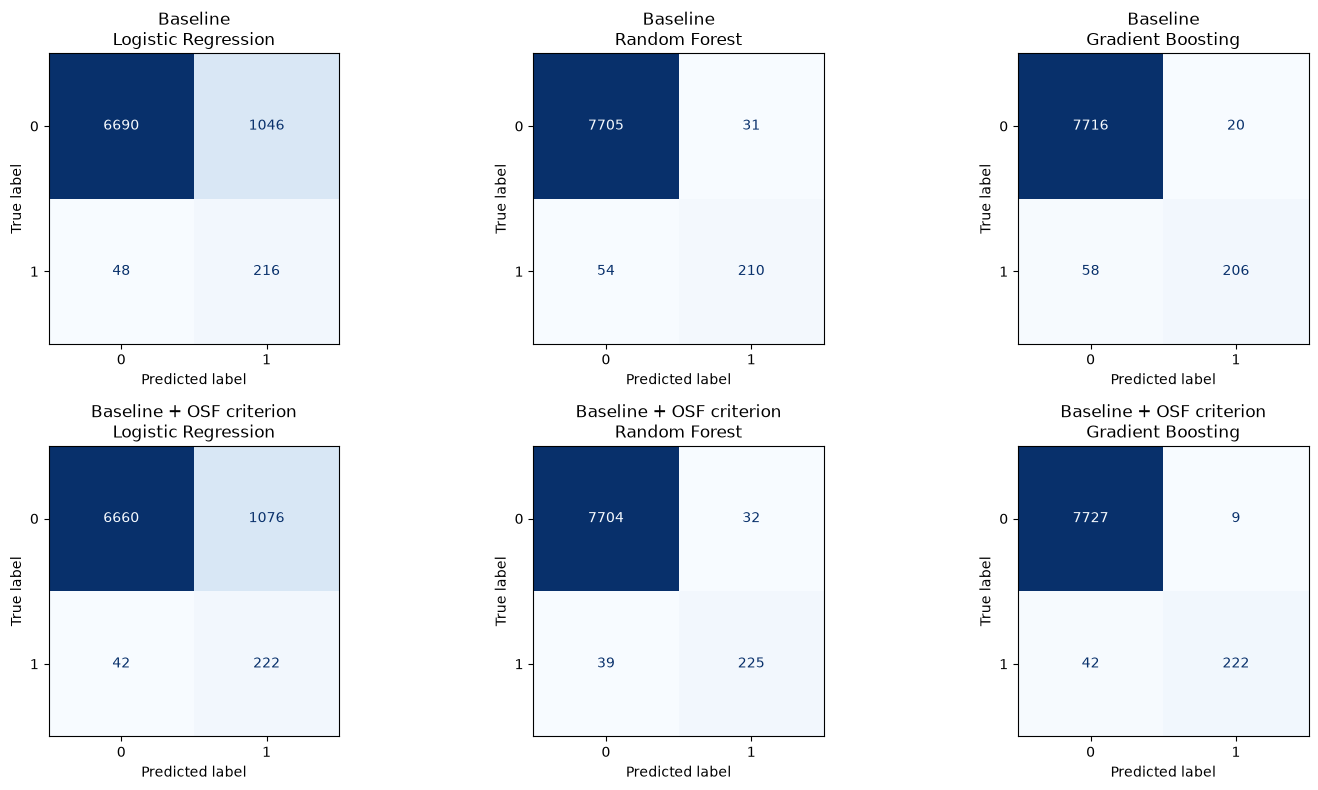

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_oof_predictions(model, X, y, cv):
    y_true_all = []
    y_pred_all = []

    for train_indices, validation_indices in cv.split(X, y):
        X_train_fold = X.iloc[train_indices]
        X_validation_fold = X.iloc[validation_indices]
        y_train_fold = y.iloc[train_indices]
        y_validation_fold = y.iloc[validation_indices]

        X_train_fold, X_validation_fold = prepare_fold_data(
            X_train_fold, X_validation_fold
        )
        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)
        y_proba = fold_model.predict_proba(X_validation_fold)[:, 1]
        y_pred = (y_proba >= DECISION_THRESHOLD).astype(int)

        y_true_all.extend(y_validation_fold)
        y_pred_all.extend(y_pred)

    return y_true_all, y_pred_all

fig, axes = plt.subplots(2, len(models), figsize=(15, 8))

for row, (feature_variant, X_features) in enumerate(feature_variants.items()):
    for column, (model_name, model) in enumerate(models.items()):
        y_true_oof, y_pred_oof = get_oof_predictions(model, X_features, y_train, cv)
        matrix = confusion_matrix(y_true_oof, y_pred_oof)
        ConfusionMatrixDisplay(matrix, display_labels=[0, 1]).plot(
            ax=axes[row, column],
            cmap="Blues",
            colorbar=False,
        )
        axes[row, column].set_title(f"{feature_variant}\n{model_name}")

plt.tight_layout()
plt.show()

## Results and summary

The confusion matrices show aggregated out-of-fold predictions from 5-fold cross-validation for 8,000 training records. Rows represent the true class and columns represent the class predicted by the model.

| Wariant cech | Model | TN | FP | FN | TP |
|---|---|---:|---:|---:|---:|
| Baseline | Logistic Regression | 6690 | 1046 | 48 | 216 |
| Baseline | Random Forest | 7705 | 31 | 54 | 210 |
| Baseline | Gradient Boosting | 7716 | 20 | 58 | 206 |
| Baseline + OSF criterion | Logistic Regression | 6660 | 1076 | 42 | 222 |
| Baseline + OSF criterion | Random Forest | 7704 | 32 | 39 | 225 |
| Baseline + OSF criterion | Gradient Boosting | 7727 | 9 | 42 | 222 |

### Interpretation

- **Logistic Regression:** OSF detected 6 additional failures and reduced false negatives from 48 to 42, but increased false positives from 1,046 to 1,076.
- **Random Forest:** OSF reduced missed failures from 54 to 39, with only a small increase in false positives from 31 to 32.
- **Gradient Boosting:** OSF improved both important error types: false negatives decreased from 58 to 42, while false positives decreased from 20 to 9.

### Conclusion

The most promising combination is **Baseline + OSF criterion + Gradient Boosting**. Compared with the baseline, it detects more failures and generates fewer false alarms. The OSF feature also appears beneficial for Random Forest. Logistic Regression still produces many false alarms, making it less practical with the current `probability >= 0.5` decision rule.

These results are used to select the experimental variant. They are not yet a final evaluation on an independent, untouched test set.